PIECEWISE LINEAR INTERPLOATING POLYNOMIALS


Calculated Piecewise Linear Polynomials:
P0(x) = 2.00x + 0.00, for x in [1, 2]
P1(x) = -3.00x + 10.00, for x in [2, 3]
P2(x) = 2.00x + -5.00, for x in [3, 4]
P3(x) = 4.00x + -13.00, for x in [4, 5]
Interpolated value at x = 2.5: 2.5


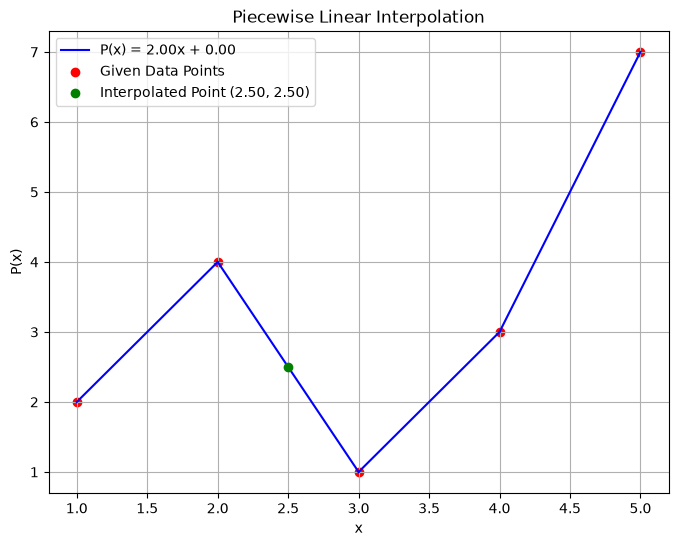

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def piecewise_linear_interpolation(x_data, y_data, x_interp):
    """
    Performs piecewise linear interpolation.
    :x_data: List or array of x values (must be sorted)
    :y_data: List or array of corresponding y values
    :x_interp: The x value where interpolation is needed
    :return: Interpolated value at x_interp and piecewise polynomials
    """

    if not np.all(np.diff(x_data) > 0):
        raise ValueError("x_data must be in strictly increasing order.")

    polynomials = []

    for i in range(len(x_data) - 1):
        x0, x1 = x_data[i], x_data[i + 1]
        y0, y1 = y_data[i], y_data[i + 1]

        # Compute coefficients of the Linear polynomial P(x) = a*x + b
        a = (y1 - y0) / (x1 - x0)
        b = y0 - a * x0

        polynomials.append((a, b, (x0, x1)))

    # Print all calculated polynomials
    print("Calculated Piecewise Linear Polynomials:")

    for i, (a, b, (x0, x1)) in enumerate(polynomials):
        print(f"P{i}(x) = {a:.2f}x + {b:.2f}, for x in [{x0}, {x1}]")

    # Find the interval where x_interp falls
    y_interp = None

    for a, b, (x0, x1) in polynomials:
        if x0 <= x_interp <= x1:
            y_interp = a * x_interp + b
            break

    return y_interp, polynomials


def plot_interpolation(x_data, y_data, polynomials, x_interp=None, y_interp=None):
    """Plots the piecewise linear interpolation."""

    plt.figure(figsize=(8, 6))

    # Plot the piecewise linear segments
    for a, b, (x0, x1) in polynomials:
        x_vals = np.linspace(x0, x1, 100)
        y_vals = a * x_vals + b

        plt.plot(
            x_vals,
            y_vals,
            'b-',
            label=f'P(x) = {a:.2f}x + {b:.2f}'
            if x0 == x_data[0] else ""
        )

    # Scatter plot of given data points
    plt.scatter(
        x_data,
        y_data,
        color='red',
        label='Given Data Points'
    )

    # Highlight interpolated point
    if x_interp is not None and y_interp is not None:
        plt.scatter(
            x_interp,
            y_interp,
            color='green',
            label=f'Interpolated Point ({x_interp:.2f}, {y_interp:.2f})',
            zorder=3
        )

    plt.xlabel('x')
    plt.ylabel('P(x)')
    plt.legend()
    plt.title('Piecewise Linear Interpolation')
    plt.grid()
    plt.show()


# Example Usage
x_data = np.array([1, 2, 3, 4, 5])  # Given x points
y_data = np.array([2, 4, 1, 3, 7])  # Given y points
x_interp = 2.5  # Point to interpolate

y_interp, polynomials = piecewise_linear_interpolation(
    x_data, y_data, x_interp
)

print(f"Interpolated value at x = {x_interp}: {y_interp}")

# Plot the interpolation
plot_interpolation(
    x_data,
    y_data,
    polynomials,
    x_interp,
    y_interp
)


PIECEWISE QUADRATIC INTERPLOATING POLYNOMIALS

Calculated Piecewise Quadratic Polynomials:
P0(x) = -2.50x^2 + 9.50x + -5.00, for x in [1, 3]
P1(x) = 1.00x^2 + -5.00x + 7.00, for x in [3, 5]
Interpolated value at x = 2.5: 3.124999999999999


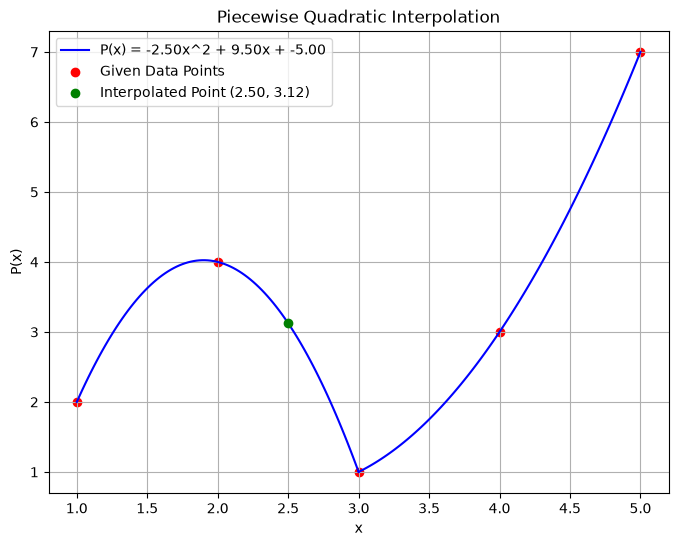

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def piecewise_quadratic_interpolation(x_data, y_data, x_interp):
    """
    Performs piecewise quadratic interpolation without overlapping subintervals.
    :input x_data: List or array of x values (must be sorted)
    :input y_data: List or array of corresponding y values
    :input x_interp: The x value where interpolation is needed
    :return: Interpolated value at x_interp and piecewise quadratic polynomials
    """

    if len(x_data) < 3 or len(x_data) % 2 == 0:
        raise ValueError("An odd number of points is required for non-overlapping quadratic interpolation.")

    if not np.all(np.diff(x_data) > 0):
        raise ValueError("x_data must be in strictly increasing order.")

    polynomials = []

    for i in range(0, len(x_data) - 2, 2):
        x0, x1, x2 = x_data[i], x_data[i + 1], x_data[i + 2]
        y0, y1, y2 = y_data[i], y_data[i + 1], y_data[i + 2]

        # Solve for coefficients a, b, c in P(x) = ax^2 + bx + c
        A = np.array([[x0**2, x0, 1],
                      [x1**2, x1, 1],
                      [x2**2, x2, 1]])

        B = np.array([y0, y1, y2])

        coeffs = np.linalg.solve(A, B)  # Solve linear system
        a, b, c = coeffs

        polynomials.append((a, b, c, (x0, x2)))

    # Print all calculated polynomials
    print("Calculated Piecewise Quadratic Polynomials:")

    for i, (a, b, c, (x0, x2)) in enumerate(polynomials):
        print(
            f"P{i}(x) = {a:.2f}x^2 + {b:.2f}x + {c:.2f}, "
            f"for x in [{x0}, {x2}]"
        )

    # Find the interval where x_interp falls
    y_interp = None

    for a, b, c, (x0, x2) in polynomials:
        if x0 <= x_interp <= x2:
            y_interp = a * x_interp**2 + b * x_interp + c
            break

    return y_interp, polynomials


def plot_interpolation(x_data, y_data, polynomials, x_interp=None, y_interp=None):
    """Plots the piecewise quadratic interpolation."""

    plt.figure(figsize=(8, 6))

    # Plot the piecewise quadratic segments
    for a, b, c, (x0, x2) in polynomials:
        x_vals = np.linspace(x0, x2, 100)
        y_vals = a * x_vals**2 + b * x_vals + c

        plt.plot(
            x_vals,
            y_vals,
            'b-',
            label=f'P(x) = {a:.2f}x^2 + {b:.2f}x + {c:.2f}'
            if x0 == x_data[0] else ""
        )

    # Scatter plot of given data points
    plt.scatter(
        x_data,
        y_data,
        color='red',
        label='Given Data Points'
    )

    # Highlight interpolated point
    if x_interp is not None and y_interp is not None:
        plt.scatter(
            x_interp,
            y_interp,
            color='green',
            label=f'Interpolated Point ({x_interp:.2f}, {y_interp:.2f})',
            zorder=3
        )

    plt.xlabel('x')
    plt.ylabel('P(x)')
    plt.legend()
    plt.title('Piecewise Quadratic Interpolation')
    plt.grid()
    plt.show()


# Example Usage
x_data = np.array([1, 2, 3, 4, 5])  # Given x points
y_data = np.array([2, 4, 1, 3, 7])  # Given y points
x_interp = 2.5  # Point to interpolate

y_interp, polynomials = piecewise_quadratic_interpolation(
    x_data, y_data, x_interp
)

print(f"Interpolated value at x = {x_interp}: {y_interp}")

# Plot the interpolation
plot_interpolation(
    x_data,
    y_data,
    polynomials,
    x_interp,
    y_interp
)

PIECEWISE CUBIC INTERPLOATING POLYNOMIALS

Calculated Piecewise Cubic Polynomials:
P0(x) = 1.67x^3 + -12.50x^2 + 27.83x + -15.00, for x in [1, 4]
P1(x) = -0.17x^3 + 1.00x^2 + 5.17x + -23.00, for x in [4, 7]
Interpolated value at x = 4.5: 5.3125


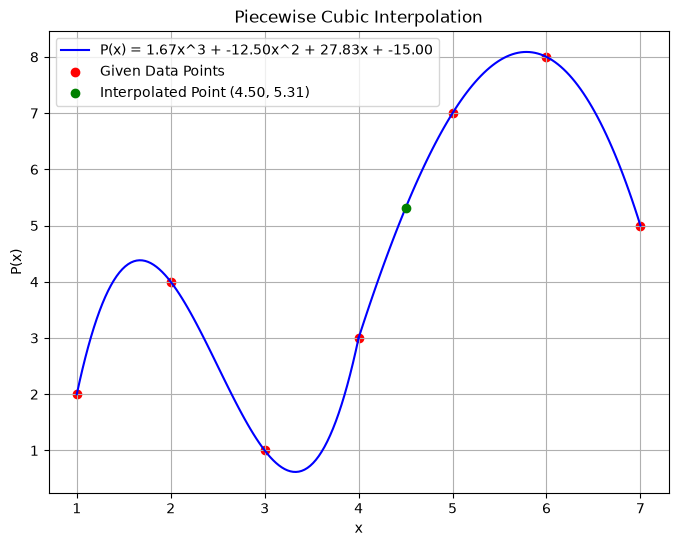

In [3]:
import numpy as np
import matplotlib.pyplot as plt


def piecewise_cubic_interpolation(x_data, y_data, x_interp):
    """
    Performs piecewise cubic interpolation without overlapping subintervals.
    :x_data: List or array of x values (must be sorted)
    :y_data: List or array of corresponding y values
    :x_interp: The x value where interpolation is needed
    :return: Interpolated value at x_interp and piecewise cubic polynomials
    """

    if len(x_data) < 4 or len(x_data) % 3 != 1:
        raise ValueError("Number of points must be 4, 7, 10, etc., for non-overlapping cubic interpolation.")

    if not np.all(np.diff(x_data) > 0):
        raise ValueError("x_data must be in strictly increasing order.")

    polynomials = []

    for i in range(0, len(x_data) - 3, 3):
        x0, x1, x2, x3 = x_data[i], x_data[i + 1], x_data[i + 2], x_data[i + 3]
        y0, y1, y2, y3 = y_data[i], y_data[i + 1], y_data[i + 2], y_data[i + 3]

        # Solve for coefficients a, b, c, d in P(x) = ax^3 + bx^2 + cx + d
        A = np.array([
            [x0**3, x0**2, x0, 1],
            [x1**3, x1**2, x1, 1],
            [x2**3, x2**2, x2, 1],
            [x3**3, x3**2, x3, 1]
        ])

        B = np.array([y0, y1, y2, y3])

        coeffs = np.linalg.solve(A, B)  # Solve linear system

        a, b, c, d = coeffs
        polynomials.append((a, b, c, d, (x0, x3)))

    # Print all calculated polynomials
    print("Calculated Piecewise Cubic Polynomials:")

    for i, (a, b, c, d, (x0, x3)) in enumerate(polynomials):
        print(
            f"P{i}(x) = {a:.2f}x^3 + {b:.2f}x^2 + {c:.2f}x + {d:.2f}, "
            f"for x in [{x0}, {x3}]"
        )

    # Find the interval where x_interp falls
    y_interp = None

    for a, b, c, d, (x0, x3) in polynomials:
        if x0 <= x_interp <= x3:
            y_interp = (
                a * x_interp**3
                + b * x_interp**2
                + c * x_interp
                + d
            )
            break

    return y_interp, polynomials


def plot_interpolation(x_data, y_data, polynomials, x_interp=None, y_interp=None):
    """Plots the piecewise cubic interpolation."""

    plt.figure(figsize=(8, 6))

    # Plot the piecewise cubic segments
    for a, b, c, d, (x0, x3) in polynomials:
        x_vals = np.linspace(x0, x3, 100)
        y_vals = a * x_vals**3 + b * x_vals**2 + c * x_vals + d

        plt.plot(
            x_vals,
            y_vals,
            'b-',
            label=f'P(x) = {a:.2f}x^3 + {b:.2f}x^2 + {c:.2f}x + {d:.2f}'
            if x0 == x_data[0] else ""
        )

    # Scatter plot of given data points
    plt.scatter(
        x_data,
        y_data,
        color='red',
        label='Given Data Points'
    )

    # Highlight interpolated point
    if x_interp is not None and y_interp is not None:
        plt.scatter(
            x_interp,
            y_interp,
            color='green',
            label=f'Interpolated Point ({x_interp:.2f}, {y_interp:.2f})',
            zorder=3
        )

    plt.xlabel('x')
    plt.ylabel('P(x)')
    plt.legend()
    plt.title('Piecewise Cubic Interpolation')
    plt.grid()
    plt.show()


# Example Usage
x_data = np.array([1, 2, 3, 4, 5, 6, 7])  # Given x points
y_data = np.array([2, 4, 1, 3, 7, 8, 5])  # Given y points
x_interp = 4.5  # Point to interpolate

y_interp, polynomials = piecewise_cubic_interpolation(
    x_data, y_data, x_interp
)

print(f"Interpolated value at x = {x_interp}: {y_interp}")

# Plot the interpolation
plot_interpolation(
    x_data,
    y_data,
    polynomials,
    x_interp,
    y_interp
)